In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# There is a set of images in F:\Documents\LiDAR_kappazunder_kg19\Los_6A\Bild-Rohdaten\Trajektorie_15767\Sensor_110021\masks\ of masks belonging to the images in F:\Documents\LiDAR_kappazunder_kg19\Los_6A\Bild-Rohdaten\Trajektorie_15767\Sensor_110021\. The images in the masks directory are named are "frame.jpg", "frame_00000.jpg", "frame_00001.jpg", etc. while the images in masks\..\ are named "WE1H2XH4.jpg", "WE1H2XH5.jpg", "WE1H2XH6.jpg", etc. There is a 1:1 correspondence (when sorted alphabetically) between the images in the two directories. Our goal is now to simply rename the masks to match the names of the images in the other directory. Do a dry run first
# image_path = r"F:\Documents\LiDAR_kappazunder_kg19\Los_6A\Bild-Rohdaten\Trajektorie_15767\Sensor_110021"
# mask_path = r"F:\Documents\LiDAR_kappazunder_kg19\Los_6A\Bild-Rohdaten\Trajektorie_15767\Sensor_110021\masks"

# import os

# # Only consider JPG files in each directory and keep the alphabetical pairing
# image_files = sorted(
# 	f for f in os.listdir(image_path) if f.lower().endswith(".jpg")
# )
# mask_files = sorted(
# 	f for f in os.listdir(mask_path) if f.lower().endswith(".jpg")
# )

# if len(image_files) != len(mask_files):
# 	print(
# 		f"Warning: {len(image_files)} image files and {len(mask_files)} mask files "
# 		f"do not match. Dry run will still process the common pairs only."
# 	)

# for image_file, mask_file in zip(image_files, mask_files):
# 	new_mask_name = image_file
# 	old_mask_path = os.path.join(mask_path, mask_file)
# 	new_mask_path = os.path.join(mask_path, new_mask_name)
	
# 	print(f"Renaming {old_mask_path} to {new_mask_path}")
# 	# Uncomment the next line to actually perform the renaming
# 	# os.rename(old_mask_path, new_mask_path)

In [3]:
EPSG = "EPSG:31256"

reduction_polygon = np.array([
	[4278.455557452173, 341299.89900089824],
	[4336.339709954783, 341359.7583090223],
	[4360.202814607671, 341320.4970523807],
	[4364.878693222089, 341312.75766708783],
	[4379.309422049343, 341291.5549761292],
	[4392.450253327791, 341274.78630799474],
	[4411.959953753463, 341251.1650591322],
	[4441.083421847587, 341218.47421812976],
	[4435.17810963195, 341212.6293698618],
	[4416.23273938388, 341197.71492945374],
	[4410.670056204659, 341191.82977188734],
	[4402.285722137428, 341166.918625476],
	[4395.5137600062035, 341166.67676968564],
	[4377.455194322936, 341187.8794606441],
	[4365.281786206092, 341202.31018947135],
	[4356.37343125966, 341213.11308144266],
	[4334.80795661558, 341238.0645371523],
	[4334.001770647576, 341239.5962904915],
	[4322.110527619533, 341252.85804966517],
	[4311.791347229095, 341265.3539321692],
	[4307.155777913077, 341270.8359967516],
	[4288.331335560209, 341293.0867294686],
	[4278.455557452173, 341299.89900089824],
])

# import camera positions
image_meta_df = pd.read_csv("../../LiDAR_kappazunder_kg19/Nachreichung_Kirche_Bilder/Los_6B/Bild-Meta/image_meta.txt", sep="\t")
image_meta_df

,trajectory_id,sensor_id,image_id,epoch_s,image_name,x_m,y_m,z_m,rx_rad,ry_rad,rz_rad
0,15760,110010,81028300,30737.92,WE1H1Y7J.jpg,4329.399,341360.660,7.398,0.000000,0.0,2.573082
1,15760,110010,81028301,30739.32,WE1H1Y7K.jpg,4331.058,341358.081,7.379,0.000000,0.0,2.572307
2,15760,110010,81028302,30751.67,WE1H1Y7L.jpg,4331.961,341356.645,7.360,0.000000,0.0,2.572026
3,15760,110010,81028303,30753.05,WE1H1Y7M.jpg,4333.676,341354.047,7.366,0.000000,0.0,2.562018
4,15760,110010,81028304,30753.80,WE1H1Y7N.jpg,4335.328,341351.517,7.363,0.000000,0.0,2.557827
...,...,...,...,...,...,...,...,...,...,...,...
1621,20727,110025,107534183,30011.36,WE1YG1YO.jpg,4340.759,341348.978,7.363,-3.141593,0.0,5.711293
1622,20727,110025,107534184,30012.09,WE1YG1YP.jpg,4339.115,341351.551,7.367,-3.141593,0.0,5.710873
1623,20727,110025,107534185,30012.69,WE1YG1YQ.jpg,4337.484,341354.102,7.353,-3.141593,0.0,5.710348
1624,20727,110025,107534186,30013.22,WE1YG1YR.jpg,4335.852,341356.653,7.341,-3.141593,0.0,5.710803


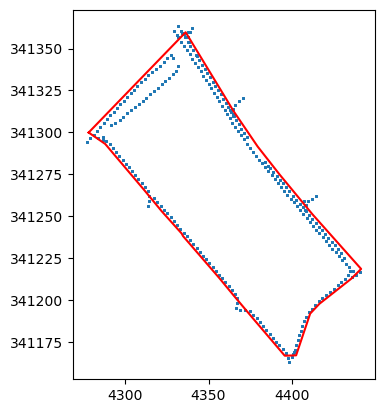

In [4]:
plt.scatter(image_meta_df["x_m"], image_meta_df["y_m"], s=1)
# Draw the reduction polygon
plt.plot(reduction_polygon[:, 0], reduction_polygon[:, 1], color="red")
# 1:1 aspect ratio
plt.gca().set_aspect("equal", adjustable="box")

In [5]:
image_meta_gdf = gpd.GeoDataFrame(
	image_meta_df,
	geometry=gpd.points_from_xy(image_meta_df["x_m"], image_meta_df["y_m"]),
	crs=EPSG,
)

In [10]:
image_meta_gdf[image_meta_gdf["sensor_id"] == 110011].head(20)

,trajectory_id,sensor_id,image_id,epoch_s,image_name,x_m,y_m,z_m,rx_rad,ry_rad,rz_rad,geometry
249,15760,110011,81028300,30737.92,WE1H1Y7J.jpg,4329.399,341360.660,7.398,-1.570796,0.0,2.573082,POINT (4329.399 341360.66)
250,15760,110011,81028301,30739.32,WE1H1Y7K.jpg,4331.058,341358.081,7.379,-1.570796,0.0,2.572307,POINT (4331.058 341358.081)
251,15760,110011,81028302,30751.67,WE1H1Y7L.jpg,4331.961,341356.645,7.360,-1.570796,0.0,2.572026,POINT (4331.961 341356.645)
252,15760,110011,81028303,30753.05,WE1H1Y7M.jpg,4333.676,341354.047,7.366,-1.570796,0.0,2.562018,POINT (4333.676 341354.047)
253,15760,110011,81028304,30753.80,WE1H1Y7N.jpg,4335.328,341351.517,7.363,-1.570796,0.0,2.557827,POINT (4335.328 341351.517)
254,15760,110011,81028305,30754.40,WE1H1Y7O.jpg,4336.997,341348.990,7.353,-1.570796,0.0,2.555018,POINT (4336.997 341348.99)
255,15760,110011,81028306,30754.92,WE1H1Y7P.jpg,4338.675,341346.474,7.333,-1.570796,0.0,2.555819,POINT (4338.675 341346.474)
256,15760,110011,81028307,30755.41,WE1H1Y7Q.jpg,4340.353,341343.971,7.332,-1.570796,0.0,2.565724,POINT (4340.353 341343.971)
257,15760,110011,81028308,30755.88,WE1H1Y7R.jpg,4341.986,341341.450,7.332,-1.570796,0.0,2.572530,POINT (4341.986 341341.45)
258,15760,110011,81028309,30756.34,WE1H1Y7S.jpg,4343.603,341338.899,7.340,-1.570796,0.0,2.575510,POINT (4343.603 341338.899)


(0.0, 20.0)

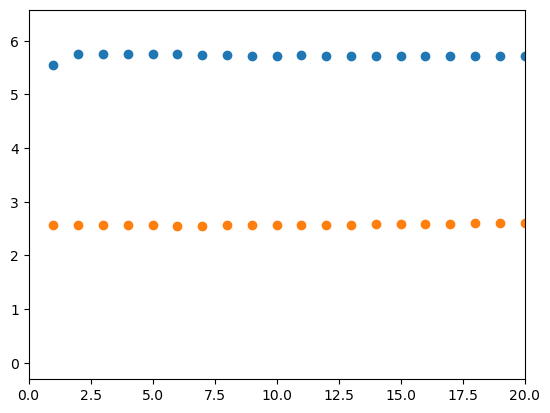

In [7]:
plt.scatter(np.arange(1, len(image_meta_gdf[image_meta_gdf["sensor_id"] == 110021]) + 1), image_meta_gdf[image_meta_gdf["sensor_id"] == 110021]["rz_rad"]) # front-facing camera
plt.scatter(np.arange(1, len(image_meta_gdf) + 1), image_meta_gdf["rz_rad"]) # up-facing camera
plt.xlim(0, 20)

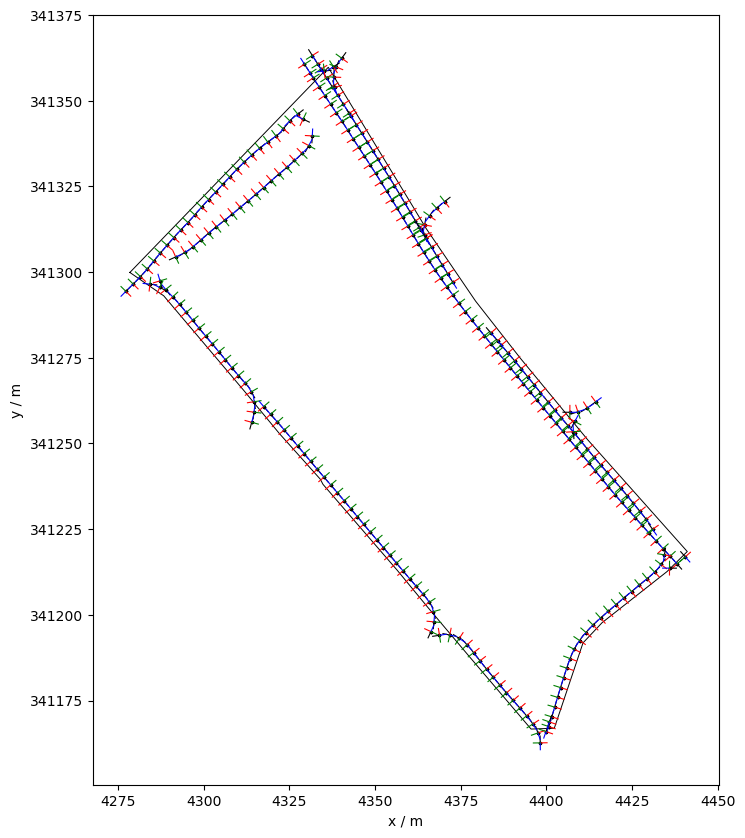

In [15]:
plt.plot(reduction_polygon[:, 0], reduction_polygon[:, 1], "k-", lw=0.7)
dir_len = 2.
dir_lw = 0.8

# Generalize to sensors with suffixes 11..14 or 21..24
# e.g. 110011..110014, 110021..110024
suffixes = {11, 12, 13, 14, 21, 22, 23, 24}
sensor_ids = sorted(
	{
		sid
		for sid in image_meta_gdf["sensor_id"].unique()
		if sid % 100 in suffixes
	}
)

# Use the longest matching sensor sequence as the number of steps
n_steps = max(len(image_meta_gdf[image_meta_gdf["sensor_id"] == sid]) for sid in sensor_ids)

# Color by the last digit of the sensor id: 1,2,3,4 -> k,r,b,g
color_by_last_digit = {1: "k", 2: "r", 3: "b", 4: "g"}

for i in range(n_steps):
	for sid in sensor_ids:
		rows = image_meta_gdf[image_meta_gdf["sensor_id"] == sid]
		if i >= len(rows):
			continue

		row = rows.iloc[i]
		x, y = row.geometry.x, row.geometry.y
		plt.scatter(x, y, s=2, c="k")
		plt.plot(
			[x, x + dir_len * np.sin(row.rz_rad)],
			[y, y + dir_len * np.cos(row.rz_rad)],
			c=color_by_last_digit[sid % 10],
			lw=dir_lw
		)

# Correct aspect ratio
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("x / m")
plt.ylabel("y / m")
plt.gcf().set_size_inches(10, 10)
plt.show()

In [12]:
n_steps

249

In [8]:
# image_meta_gdf[image_meta_gdf["sensor_id"] == 110024].iloc[40:80][["sensor_id", "image_name", "x_m", "y_m", "rz_rad"]] # front-facing camera

In [9]:
from build_colmap_selection import *

In [10]:
image_meta_gdf = load_image_meta(IMAGE_META_PATH)
image_meta_gdf.head()

,trajectory_id,sensor_id,image_id,epoch_s,image_name,x_m,y_m,z_m,rx_rad,ry_rad,rz_rad,geometry
0,15767,110020,81077806,544305.54,WE1H2XH4.jpg,3708.061,340916.770,11.990,0.0,0.0,3.534082,POINT (3708.061 340916.77)
1,15767,110020,81077807,544306.76,WE1H2XH5.jpg,3706.875,340914.002,11.903,0.0,0.0,3.545221,POINT (3706.875 340914.002)
2,15767,110020,81077808,544308.01,WE1H2XH6.jpg,3705.571,340911.288,11.863,0.0,0.0,3.603837,POINT (3705.571 340911.288)
3,15767,110020,81077809,544309.27,WE1H2XH7.jpg,3704.008,340908.711,11.836,0.0,0.0,3.697283,POINT (3704.008 340908.711)
4,15767,110020,81077810,544310.42,WE1H2XH8.jpg,3702.398,340906.151,11.821,0.0,0.0,3.658704,POINT (3702.398 340906.151)


In [11]:
interior_df = load_interior_orientation(INTERIOR_ORIENTATION_PATH)
interior_df.head()

f:\Documents\LiDAR_kappazunder_stadpark_reduced\colmap_pipeline\build_colmap_selection.py:88: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv(path, sep="\t", index_col=False)


,sensor_id,type_projection,c_mm,psu_mm,psv_mm,pix_u,pix_v,dh_m,pitch_rad
0,110010,p,16.399,0.0046,0.0046,7130,7130,2.09,1.570796
1,110011,p,16.399,0.0046,0.0046,7130,7130,2.09,0.000000
2,110012,p,16.399,0.0046,0.0046,7130,7130,2.09,0.000000
3,110013,p,16.399,0.0046,0.0046,7130,7130,2.09,0.000000
4,110014,p,16.399,0.0046,0.0046,7130,7130,2.09,0.000000


In [12]:
fov_by_sensor = load_fov_per_sensor(INTERIOR_ORIENTATION_PATH)
fov_by_sensor

f:\Documents\LiDAR_kappazunder_stadpark_reduced\colmap_pipeline\build_colmap_selection.py:88: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv(path, sep="\t", index_col=False)


{110010: np.float64(1.5707963267948966),
 110011: np.float64(1.5707963267948966),
 110012: np.float64(1.5707963267948966),
 110013: np.float64(1.5707963267948966),
 110014: np.float64(1.5707963267948966),
 110015: np.float64(1.5707963267948966),
 110020: np.float64(1.5707963267948966),
 110021: np.float64(1.5707963267948966),
 110022: np.float64(1.5707963267948966),
 110023: np.float64(1.5707963267948966),
 110024: np.float64(1.5707963267948966),
 110025: np.float64(1.5707963267948966),
 110030: np.float64(1.5707963267948966),
 110031: np.float64(1.5707963267948966),
 110032: np.float64(1.5707963267948966),
 110033: np.float64(1.5707963267948966),
 110034: np.float64(1.5707963267948966),
 110035: np.float64(1.5707963267948966)}

In [ ]:
fov = np.pi / 2

row = image_meta_gdf.iloc[165]
frustum = make_frustum(row["x_m"], row["y_m"], row["rz_rad"], fov, 10)
fx, fy = frustum.exterior.xy
plt.plot(fx, fy, "r-")

row = image_meta_gdf.iloc[393]
frustum = make_frustum(row["x_m"], row["y_m"], row["rz_rad"], fov, 10)
fx, fy = frustum.exterior.xy
plt.plot(fx, fy, "b-")
plt.scatter(image_meta_gdf["x_m"], image_meta_gdf["y_m"], s=4, c="k")

In [14]:
pitch_by_sensor = interior_df.set_index("sensor_id")["pitch_rad"].to_dict()

image_meta_gdf = image_meta_gdf.copy()
image_meta_gdf["pitch_rad"] = image_meta_gdf["sensor_id"].map(pitch_by_sensor)

In [15]:
print(f"Loaded {len(image_meta_gdf)} image records.")
print(f"FOV by sensor (deg): "
	  f"{ {k: round(np.degrees(v),1) for k,v in fov_by_sensor.items()} }")

Loaded 1620 image records.
FOV by sensor (deg): {110010: np.float64(90.0), 110011: np.float64(90.0), 110012: np.float64(90.0), 110013: np.float64(90.0), 110014: np.float64(90.0), 110015: np.float64(90.0), 110020: np.float64(90.0), 110021: np.float64(90.0), 110022: np.float64(90.0), 110023: np.float64(90.0), 110024: np.float64(90.0), 110025: np.float64(90.0), 110030: np.float64(90.0), 110031: np.float64(90.0), 110032: np.float64(90.0), 110033: np.float64(90.0), 110034: np.float64(90.0), 110035: np.float64(90.0)}


In [16]:
image_meta_gdf = select_images(
	image_meta_gdf, REDUCTION_POLYGON, fov_by_sensor, 30 # TODO: change back to MAX_FRUSTUM_DIST after testing
)

# TODO: remove this, it's just for debugging
# image_meta_gdf["selected"] = False
# image_meta_gdf.loc[0:227, "selected"] = True

n_selected = image_meta_gdf["selected"].sum()
print(f"Selected {n_selected} / {len(image_meta_gdf)} images "
	  f"(frustum intersects ROI).")

plot_path = OUTPUT_DIR / "selection_preview.png"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plot_selection(image_meta_gdf, REDUCTION_POLYGON, fov_by_sensor,
				30, plot_path) # TODO: change back to MAX_FRUSTUM_DIST after testing

print(f"Saved selection preview: {plot_path}")

Found 228 mask images for selected images.
Selected 512 / 1620 images (frustum intersects ROI).
Saved selection preview: colmap_export\selection_preview.png


In [17]:
with np.printoptions(threshold=np.inf):
	print(image_meta_gdf["mask_path"].to_numpy())

[None None None None None None None None None None None None None None
 None None None None None None None None None None None None None None
 None None None None None None None None None None None None None None
 None None None None None None None None None None None None None None
 None None None None None None None None None None None None None None
 None None None None None None None None None None None None None None
 None None None None None None None None None None None None None None
 None None None None None None None None None None None None None None
 None None None None None None None None None None None None None None
 None None None None None None None None None None None None None None
 None None None None None None None None None None None None None None
 None None None None None None None None None None None None None None
 None None None None None None None None None None None None None None
 None None None None None None None None None None None None None None
 None 

In [18]:
selected_gdf = image_meta_gdf[image_meta_gdf["selected"]].copy()

if len(selected_gdf) == 0:
	print("No images selected -- check ROI polygon / MAX_FRUSTUM_DIST.")
else:
	# Center the scene on the selected images' centroid (in x,y; z kept
	# at the mean camera height so vertical values also stay small).
	scene_origin = (
		selected_gdf["x_m"].mean(),
		selected_gdf["y_m"].mean(),
		selected_gdf["z_m"].mean(),
	)
	print(f"Scene origin (EPSG:31256): "
			f"x={scene_origin[0]:.3f} y={scene_origin[1]:.3f} z={scene_origin[2]:.3f}")

	name_map = copy_and_rename_images(
		selected_gdf, RAW_IMAGES_ROOT, OUTPUT_IMAGES_DIR, copy=COPY_IMAGES, invert_masks=True
	)
	export_colmap(selected_gdf, interior_df, OUTPUT_SPARSE_DIR, name_map,
					scene_origin, INVERT_Y_AXIS)
	print(f"\nDone. COLMAP-format export at: {OUTPUT_DIR}")
	print(f"  {OUTPUT_DIR}/images/        <- (renamed) images"
			f"{'(not copied -- COPY_IMAGES=False)' if not COPY_IMAGES else ''}")
	print(f"  {OUTPUT_DIR}/sparse/0/      <- cameras.txt, images.txt, points3D.txt")
	print(f"  {OUTPUT_DIR}/scene_origin.txt  <- offset, reuse for LiDAR PLY export")

Scene origin (EPSG:31256): x=3613.603 y=340871.770 z=12.634
Wrote colmap_export\sparse\0\cameras.txt
Wrote colmap_export\sparse\0\images.txt
Wrote colmap_export\sparse\0\points3D.txt
Wrote colmap_export\scene_origin.txt  (offset: 3613.603, 340871.770, 12.634)

Done. COLMAP-format export at: colmap_export
  colmap_export/images/        <- (renamed) images
  colmap_export/sparse/0/      <- cameras.txt, images.txt, points3D.txt
  colmap_export/scene_origin.txt  <- offset, reuse for LiDAR PLY export


In [ ]:
interior_df.iloc[0]

sensor_id            110010
type_projection           p
c_mm                 16.399
psu_mm               0.0046
psv_mm               0.0046
pix_u                  7130
pix_v                  7130
dh_m                   2.09
pitch_rad          1.570796
Name: 0, dtype: object

In [ ]:
from laz_to_ply import *

In [ ]:
main()

Trajektorie_15767_AoI_thin.laz: 1,059,344 points
Total merged points: 1,059,344
Voxel downsampled (0.03 m): 1,059,344 -> 990,010 points
Wrote colmap_export\sparse\0\points3D_init.ply (990,010 points)


In [21]:
f = open("colmap_export/scene_origin.txt", "r")
lines = f.readlines()[3:6]
scene_origin = pd.DataFrame([line.strip().split() for line in lines], columns=["axis", "value"]).values[:, 1].astype(float)
scene_origin

array([3.60922875e+03, 3.40869381e+05, 1.27301390e+01])

In [19]:
import rotation_conversion

In [22]:
rotation_conversion.__main__()

AttributeError: module 'rotation_conversion' has no attribute '__main__'

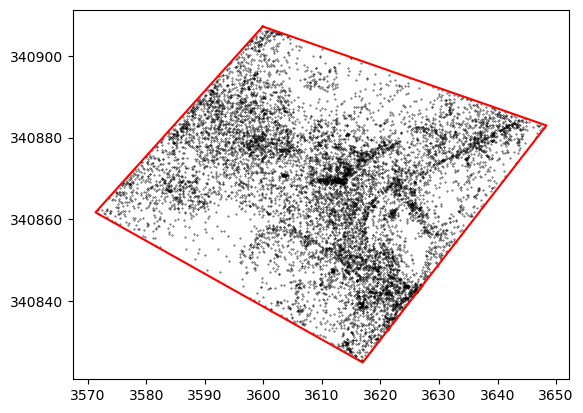

In [ ]:
LAZ_PATHS = [
    "data/Trajektorie_15767_AoI_thin.laz",
]

point_cloud_xy = read_laz_as_arrays(LAZ_PATHS[0])[0][:, :2][::100]

plt.scatter(point_cloud_xy[:, 0], point_cloud_xy[:, 1], s=0.1, c="k")
plt.plot(reduction_polygon[:, 0], reduction_polygon[:, 1], "r-")

In [ ]:
plt.plot(reduction_polygon[:, 0], reduction_polygon[:, 1], "r-")
dir_len = 1.
for i in range(0, len(image_meta_gdf[image_meta_gdf["sensor_id"] == 110021])):
	selection = image_meta_gdf[image_meta_gdf["sensor_id"] == 110021].iloc[i] # front-facing camera
	x, y = selection.geometry.x, selection.geometry.y
	plt.scatter(x, y, s=4, c="k")
	# Plot a small line from the camera position in the direction of the camera orientation (rz_rad)
	plt.plot(
		[x, x + dir_len * np.sin(selection.rz_rad)],
		[y, y + dir_len * np.cos(selection.rz_rad)],
		c="k",
	)
	selection = image_meta_gdf[image_meta_gdf["sensor_id"] == 110022].iloc[i] # right-racing camera (same position)
	plt.plot(
		[x, x + dir_len * np.sin(selection.rz_rad)],
		[y, y + dir_len * np.cos(selection.rz_rad)],
		c="r",
	)
	selection = image_meta_gdf[image_meta_gdf["sensor_id"] == 110023].iloc[i] # back-facing camera (same position)
	plt.plot(
		[x, x + dir_len * np.sin(selection.rz_rad)],
		[y, y + dir_len * np.cos(selection.rz_rad)],
		c="b",
	)
	selection = image_meta_gdf[image_meta_gdf["sensor_id"] == 110024].iloc[i] # left-facing camera (same position)
	plt.plot(
		[x, x + dir_len * np.sin(selection.rz_rad)],
		[y, y + dir_len * np.cos(selection.rz_rad)],
		c="g",
	)
	# Up and down work similarly, but we don't need to draw them right now

# Correct aspect ratio
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("x / m")
plt.ylabel("y / m")
plt.show()